In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [2]:
import finesse
import finesse.thermal.hello_vinet as hv
from finesse.materials import FusedSilica

In [3]:
def oned_to_twod(raveled_incides, shape):

    xys_idx = np.unravel_index(raveled_incides, shape)
    xs_idx = xys_idx[0]
    ys_idx = xys_idx[1]
    return list(zip(xys_idx[0],xys_idx[1])), xs_idx, ys_idx


Text(0.5, 1.0, 'Coating thermal deformtion')

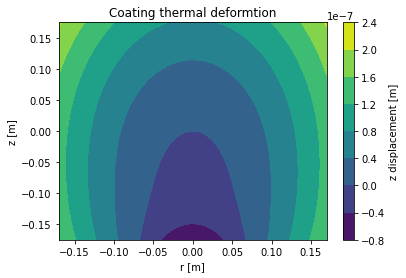

In [33]:
w = 53e-3
a = 170e-3 # radius
h = 0.35 # thickness
z = np.linspace(-h/2, h/2, 1000)
r = np.linspace(-a, a, 100)
# z displacement throughout the substrate
U_z_coat = hv.substrate_thermal_expansion_depth_HG00(r, z, a, h, w, FusedSilica)

plt.contourf(r, z, U_z_coat)
plt.colorbar(label='z displacement [m]')
plt.xlabel("r [m]")
plt.ylabel("z [m]")
plt.title("Coating thermal deformtion")

In [21]:
B = np.load("B_matrix_dimensionless_physical_dimension.npy").real
xy_ravel = np.load("xy_ravel_indices_dimensionless_physical_dimension.npy")

In [22]:
B = np.reshape(B, (9, 1000,100))

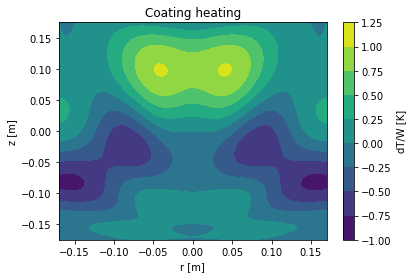

In [39]:
plt.title("Coating heating")
plt.contourf(r, z, B[6])
plt.xlabel("r [m]")
plt.ylabel("z [m]")
plt.colorbar(label='dT/W [K]')

In [28]:
#xys, xs, ys = oned_to_twod(xy_ravel, len(z))
xys_idx, xs_idx, ys_idx = oned_to_twod(xy_ravel, (1000,100) )
rs = r[ys_idx]
zs = z[xs_idx]

print(xys_idx)
print(rs)
print(zs)


[(0, 30), (15, 49), (85, 22), (219, 50), (455, 0), (660, 21), (775, 59), (999, 0), (999, 49)]
[-0.0669697  -0.00171717 -0.09444444  0.00171717 -0.17       -0.09787879
  0.03262626 -0.17       -0.00171717]
[-0.175      -0.16974474 -0.14522022 -0.09827327 -0.01559059  0.05623123
  0.09652152  0.175       0.175     ]


TypeError: scatter() missing 1 required positional argument: 'y'

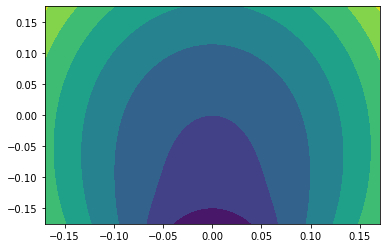

In [41]:
plt.contourf(r, z, U_z_coat)
plt.scatter(np.array([U_z_coat[i] for i in xys_idx]))
plt.colorbar(label='z displacement [m]')
plt.xlabel("r [m]")
plt.ylabel("z [m]")
plt.title("Coating thermal deformtion")

In [29]:
_U = hv.substrate_thermal_expansion_depth_HG00(rs, zs, a, h, w, FusedSilica)
print(_U[0][0], U_z_coat[0][30])

2.1426082486040038e-07 -4.5024528964845783e-10


In [30]:

U_z_coat_nodes_exact = np.array([U_z_coat[i] for i in xys_idx])



Text(0.5, 1.0, 'Coating thermal deformtion')

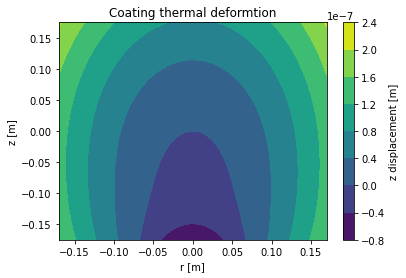

In [31]:
U_z_coat_ROM = np.einsum('kij,k->ij', np.reshape(B, (9, 1000,100)), U_z_coat_nodes_exact
                       )


plt.contourf(r, z, U_z_coat_ROM)
plt.colorbar(label='z displacement [m]')
plt.xlabel("r [m]")
plt.ylabel("z [m]")
plt.title("Coating thermal deformtion")

In [42]:
hv.substrate_thermal_expansion_depth_HG00(rs, zs, a, h, w, FusedSilica)

array([[2.14260825e-07, 3.04401724e-09, 3.25698816e-07, 3.04401724e-09,
        5.62900705e-07, 3.35676249e-07, 1.21275597e-07, 5.62900705e-07,
        3.04401724e-09],
       [2.09759747e-07, 4.59952190e-08, 3.10656989e-07, 4.59952190e-08,
        5.53631023e-07, 3.21050688e-07, 1.18394917e-07, 5.53631023e-07,
        4.59952190e-08],
       [1.76192528e-07, 7.90661061e-08, 2.53013276e-07, 7.90661061e-08,
        5.10543412e-07, 2.63187601e-07, 1.05488873e-07, 5.10543412e-07,
        7.90661061e-08],
       [1.16184009e-07, 4.80569308e-08, 1.79484886e-07, 4.80569308e-08,
        4.45262943e-07, 1.88659927e-07, 6.46727927e-08, 4.45262943e-07,
        4.80569308e-08],
       [6.24239911e-08, 1.72392919e-09, 1.22196181e-07, 1.72392919e-09,
        3.90123456e-07, 1.31080670e-07, 1.61337823e-08, 3.90123456e-07,
        1.72392919e-09],
       [7.57622807e-08, 1.55680436e-08, 1.35294092e-07, 1.55680436e-08,
        4.03367771e-07, 1.44158762e-07, 2.98279153e-08, 4.03367771e-07,
        1.5

Text(0.5, 1.0, 'Coating thermal deformtion')

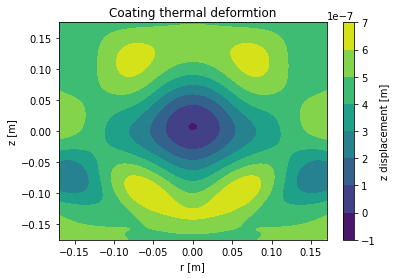

In [44]:
U_z_coat_nodes_attempt = np.diag(hv.substrate_thermal_expansion_depth_HG00(np.atleast_1d(rs[0]), np.atleast_1d(zs[0]), a, h, w, FusedSilica))


U_z_coat_ROM_attempt = np.einsum('kij,k->ij', np.reshape(B, (9, 1000,100)), U_z_coat_nodes_attempt
                       )


plt.contourf(r, z, U_z_coat_ROM_attempt)
plt.colorbar(label='z displacement [m]')
plt.xlabel("r [m]")
plt.ylabel("z [m]")
plt.title("Coating thermal deformtion")

In [45]:
print(U_z_coat_nodes_exact)

print(U_z_coat_nodes_attempt)

[-4.50245290e-10 -6.57422925e-08  3.56096895e-08 -1.72913922e-08
  1.34893613e-07  5.97692466e-08  3.62292608e-08  2.04815644e-07
  7.58964470e-08]
[4.88425547e-07]


In [63]:
t1=time.time()


for i in range(1000):
    _U_z_coat_nodes_attempt = np.diag(hv.substrate_thermal_expansion_depth_HG00(rs, 
                                                zs, a, h, w, FusedSilica))
    #_U_z_coat_nodes_attempt = hv.substrate_thermal_expansion_depth_HG00(np.array([0.1,0.11,0.12]), 
    #                                            np.array([z[0],z[1],z[-1]]), a, h, w, FusedSilica).reshape(9,)
    U_z_coat_ROM = np.einsum('kij,k->ij',B, _U_z_coat_nodes_attempt)
                       
t2=time.time()

t_ROM = (t2-t1)/1000

print(t_ROM)

t1=time.time()


for i in range(1000):
    _U_z_coat_nodes_attempt = np.diag(hv.substrate_thermal_expansion_depth_HG00(rs, 
                                                zs, a, h, w, FusedSilica))
    #_U_z_coat_nodes_attempt = hv.substrate_thermal_expansion_depth_HG00(np.array([0.1,0.11,0.12]), 
    #                                            np.array([z[0],z[1],z[-1]]), a, h, w, FusedSilica).reshape(9,)
    #U_z_coat_ROM = np.einsum('kij,k->ij',B, _U_z_coat_nodes_attempt)
                       
t2=time.time()

t_ROQ = (t2-t1)/1000

print(t_ROQ)

t3=time.time()


for i in range(1000):
    
    U_z_coat = hv.substrate_thermal_expansion_depth_HG00(r, z, a, h, w, FusedSilica)

t4=time.time()

t_full = (t4-t3)/1000

print(t_full)
print("Estimated ROM speedup=%f"%(t_full/t_ROM))
print("Estimated ROQ speedup=%f"%(t_full/t_ROQ))

0.0049049782752990725
0.001295565128326416
0.03626457071304321
Estimated ROM speedup=7.393421
Estimated ROQ speedup=27.991314


In [56]:
_U_z_coat_nodes_attempt.shape

(3, 3)

Text(0.5, 1.0, 'abs( U_ROM - U )')

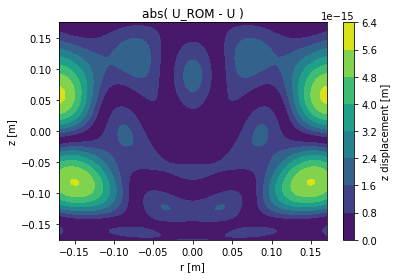

In [32]:
diff_exact_ROM = abs(U_z_coat_ROM -U_z_coat)


plt.contourf(r, z, diff_exact_ROM)
plt.colorbar(label='z displacement [m]')
plt.xlabel("r [m]")
plt.ylabel("z [m]")
plt.title("abs( U_ROM - U )")

Text(0.5, 1.0, 'Coating thermal deformtion')

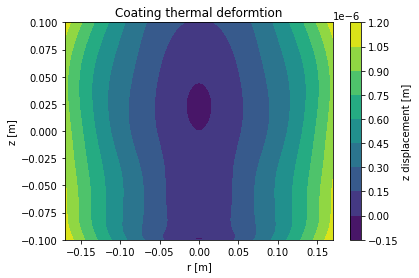

In [26]:
U_z_coat_ROM = np.einsum('kij,k->ij',np.reshape(B, (9, 1000,100)), U_z_coat_nodes_attempt
                       )


plt.contourf(r, z, U_z_coat_ROM)
plt.colorbar(label='z displacement [m]')
plt.xlabel("r [m]")
plt.ylabel("z [m]")
plt.title("Coating thermal deformtion")

In [ ]:
w = 53e-3
a = 170e-3 # radius
h = 0.2 # thickness
z = np.linspace(-0.5/2, 0.5/2, 1000)
r = np.linspace(-a, a, 100)
# z displacement throughout the substrate
U_z_coat = hv.substrate_thermal_expansion_depth_HG00(r, z, a, h, w, FusedSilica)

plt.contourf(r, z, U_z_coat)
plt.colorbar(label='z displacement [m]')
plt.xlabel("r [m]")
plt.ylabel("z [m]")
plt.title("Coating thermal deformtion")

In [113]:
B = np.load("B_matrix.npy")
xy_ravel = np.load("xy_ravel_indices.npy")

In [134]:
w = 53e-3
a = 170e-3 # radius
h = 0.2 # thickness
z = np.linspace(-0.5/2, 0.5/2, 1000)
r = np.linspace(-a, a, 100)
# z displacement throughout the substrate
U_z_coat = hv.substrate_thermal_expansion_depth_HG00(r, z, a, h, w, FusedSilica)
U_z_coat_ravel = U_z_coat.ravel()


In [193]:
list(zip(np.unravel_index(xy_ravel, (1000,100))))

[(array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0, 999]),),
 (array([ 9, 14, 17, 19, 27, 30, 32, 35, 38, 43, 46, 49, 55, 59, 75, 78,  0]),)]

In [135]:
U_z_coat_nodes = U_z_coat_ravel[xy_ravel]

In [136]:
U_z_coat_EI = np.dot(U_z_coat_nodes, B)

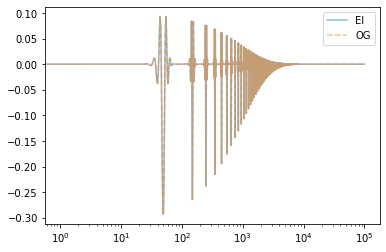

In [137]:
plt.plot(U_z_coat_EI,alpha=0.5,label='EI')
plt.plot(U_z_coat_ravel,alpha=0.5,label='OG',linestyle='--')
plt.legend()
plt.xscale("log")

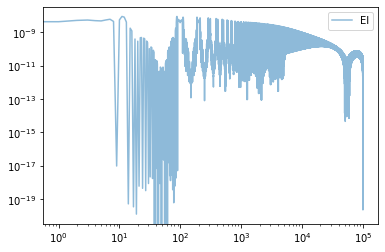

In [139]:
plt.loglog(np.abs(U_z_coat_EI-U_z_coat_ravel),alpha=0.5)
plt.legend()


Text(0.5, 1.0, 'Coating thermal deformtion')

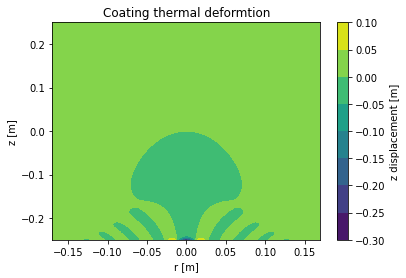

In [140]:
w = 53e-3
a = 170e-3 # radius
h = 0.2 # thickness
z = np.linspace(-0.5/2, 0.5/2, 1000)
r = np.linspace(-a, a, 100)
# z displacement throughout the substrate
U_z_coat = hv.substrate_thermal_expansion_depth_HG00(r, z, a, h, w, FusedSilica)

plt.contourf(r, z, U_z_coat_EI.reshape(1000,100))
plt.colorbar(label='z displacement [m]')
plt.xlabel("r [m]")
plt.ylabel("z [m]")
plt.title("Coating thermal deformtion")

Text(0.5, 1.0, 'Coating thermal deformtion')

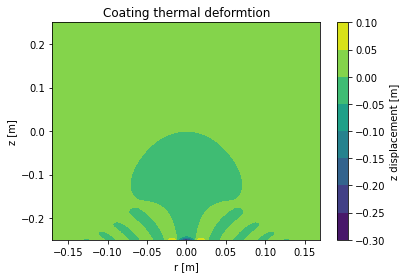

In [141]:
w = 53e-3
a = 170e-3 # radius
h = 0.2 # thickness
z = np.linspace(-0.5/2, 0.5/2, 1000)
r = np.linspace(-a, a, 100)
# z displacement throughout the substrate
U_z_coat = hv.substrate_thermal_expansion_depth_HG00(r, z, a, h, w, FusedSilica)

plt.contourf(r, z, U_z_coat_ravel.reshape(1000,100))
plt.colorbar(label='z displacement [m]')
plt.xlabel("r [m]")
plt.ylabel("z [m]")
plt.title("Coating thermal deformtion")

In [221]:
_U_z_coat_EI = np.einsum('k,kij->ij',U_z_coat_nodes, B.reshape((17,1000,100)))

/fred/oz170/rsmith/envs/finesse/lib/python3.8/site-packages/numpy/ma/core.py:2826: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,


Text(0.5, 1.0, 'Coating thermal deformtion')

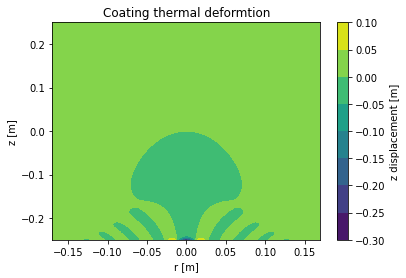

In [222]:


plt.contourf(r, z, _U_z_coat_EI)
plt.colorbar(label='z displacement [m]')
plt.xlabel("r [m]")
plt.ylabel("z [m]")
plt.title("Coating thermal deformtion")

In [212]:
np.where(U_z_coat == U_z_coat_nodes)

/tmp/ipykernel_11771/177823374.py:1: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  np.where(U_z_coat== U_z_coat_nodes)


(array([], dtype=int64),)

In [224]:
U_z_coat_nodes, U_z_coat_nodes_exact

(array([ 4.44491203e-07, -3.53983387e-08,  4.61552683e-06,  3.78126607e-06,
         5.19319146e-04, -2.18823334e-03, -1.98181755e-03,  1.17326056e-02,
        -1.55245435e-02,  6.51333021e-02,  4.67516205e-03, -2.92775321e-01,
         9.31086661e-02, -3.76251520e-02,  3.56128445e-05, -4.04234729e-05,
         3.56850224e-07]),
 array([3.52471962e-07, 3.10379045e-07, 2.97737904e-07, 2.92054790e-07,
        2.79712304e-07, 2.77050755e-07, 2.75526168e-07, 2.73471568e-07,
        2.71593275e-07, 2.68679931e-07, 2.67007379e-07, 2.65370172e-07,
        2.62170272e-07, 2.60080019e-07, 2.52003105e-07, 2.50536869e-07,
        3.02555622e-07]))

In [220]:
U_z_coat[999][0]

3.5685022427676086e-07

In [226]:
xys

[(9, 0),
 (14, 0),
 (17, 0),
 (19, 0),
 (27, 0),
 (30, 0),
 (32, 0),
 (35, 0),
 (38, 0),
 (43, 0),
 (46, 0),
 (49, 0),
 (55, 0),
 (59, 0),
 (75, 0),
 (78, 0),
 (900, 99)]

In [304]:
np.reshape(B, (17, 1000,100))

array([[[ 8.19411494e-01+0.j,  8.17143603e-01+0.j,  8.07003224e-01+0.j,
         ...,  8.07003224e-01+0.j,  8.17143603e-01+0.j,
          8.19411494e-01+0.j],
        [ 8.10965127e-01+0.j,  8.10335344e-01+0.j,  8.03145209e-01+0.j,
         ...,  8.03145209e-01+0.j,  8.10335344e-01+0.j,
          8.10965127e-01+0.j],
        [ 8.02954666e-01+0.j,  8.03685587e-01+0.j,  7.98951722e-01+0.j,
         ...,  7.98951722e-01+0.j,  8.03685587e-01+0.j,
          8.02954666e-01+0.j],
        ...,
        [-2.23550406e-04+0.j, -1.64289852e-03+0.j, -3.03111549e-03+0.j,
         ..., -3.03111549e-03+0.j, -1.64289853e-03+0.j,
         -2.23550406e-04+0.j],
        [-1.12071012e-04+0.j, -1.53136070e-03+0.j, -2.91951869e-03+0.j,
         ..., -2.91951869e-03+0.j, -1.53136070e-03+0.j,
         -1.12071012e-04+0.j],
        [ 2.89479325e-18+0.j, -1.41922775e-03+0.j, -2.80732325e-03+0.j,
         ..., -2.80732325e-03+0.j, -1.41922775e-03+0.j,
          2.89479325e-18+0.j]],

       [[-2.64820393e-02+0.j, -